# Partial Least Squares Regression: Predicting Product Quality from Correlated Process Variables

This Notebook applies Partial Least Squares Regression (PLS Regression) to predict product quality from many correlated manufacturing process variables.

# 部分最小二乗法：相関の強い工程変数から製品品質を予測する

このNotebookでは、Partial Least Squares Regression（PLS回帰）を使って、互いに相関の強い複数の工程変数から製品品質スコアを予測します。

## 1. Learning Objectives / 学習目標

- Understand why multicollinearity is a problem in regression
- Understand the basic idea of PLS
- Compare ordinary linear regression and PLS Regression
- Select the number of PLS components using cross-validation
- Evaluate prediction performance with RMSE and R²
- Interpret PLS coefficients and latent components
- Understand the relationship between PLS and PCA

- 多重共線性が回帰分析で問題になる理由を理解する
- PLSの基本的な考え方を理解する
- 通常の線形回帰とPLS回帰を比較する
- クロスバリデーションで成分数を選ぶ
- RMSE・R²で予測性能を評価する
- PLS係数と潜在成分を解釈する
- PLSとPCAの違いを理解する

## 2. Use Case / ユースケース

A manufacturer records many process variables for each production batch.

Examples include:

- temperature
- pressure
- flow rate
- mixing speed
- material purity
- viscosity
- humidity
- cycle time

The company wants to predict the final product quality score.

However, many process variables are strongly correlated with each other.

A manufacturing process often creates this situation because several sensors may reflect the same underlying process condition.

製造現場では、温度・圧力・流量・回転数など複数の工程変数を記録します。

しかし、これらは互いに強く相関することがあります。

このような状況で、

> 多重共線性を抑えつつ、品質予測に役立つ情報を抽出する

のがPLS回帰の代表的なユースケースです。

## 3. What Is PLS? / PLSとは

Partial Least Squares creates a small number of **latent components** from the original explanatory variables.

The key idea is:

> Find new components that summarize the predictors while also being strongly related to the target variable.

This differs from PCA.

PCA finds components that explain variation in **X**.

PLS finds components that are useful for explaining **Y** from **X**.

PLSは、元の説明変数を少数の潜在成分へ変換します。

重要なのは、

> 説明変数Xの情報をまとめながら、目的変数Yの予測にも役立つ成分を作る

という点です。

PCAがXの分散を最大化するのに対し、PLSはXとYの関係を意識して成分を作ります。

## 4. PLS vs PCA + Regression / PLSとPCA回帰の違い

A common alternative is:

1. apply PCA to X
2. regress Y on principal components

This is called Principal Component Regression (PCR).

The difference is:

- PCR creates components without looking at Y.
- PLS creates components while considering Y.

つまり、PLSは「予測対象Yを見ながら」成分を作る点が特徴です。

## 5. Import Libraries / ライブラリの読み込み

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

## 6. Load the Dataset / データの読み込み

In [2]:
candidate_paths = [
    Path("../data/manufacturing_quality.csv"),
    Path("11_partial_least_squares/data/manufacturing_quality.csv"),
    Path("data/manufacturing_quality.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError("manufacturing_quality.csv was not found.")

df = pd.read_csv(data_path)
df.head()

,batch_id,temperature,pressure,flow_rate,mixing_speed,material_purity,viscosity,humidity,cycle_time,quality_score
0,B001,174.84,51.71,99.88,1206.62,91.10,66.30,43.33,33.39,75.30
1,B002,179.75,52.18,88.87,1101.25,93.91,67.39,46.32,38.33,75.16
2,B003,182.57,53.29,103.22,1271.51,93.48,68.07,41.65,33.59,83.56
3,B004,169.12,46.70,106.46,1226.28,96.53,77.90,40.54,35.10,82.81
4,B005,175.07,46.89,75.96,1031.24,92.03,64.30,48.83,40.74,71.25


## 7. Understand the Dataset / データの確認

In [3]:
print("Shape:", df.shape)
print()
df.info()

Shape: (220, 10)

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   batch_id         220 non-null    str    
 1   temperature      220 non-null    float64
 2   pressure         220 non-null    float64
 3   flow_rate        220 non-null    float64
 4   mixing_speed     220 non-null    float64
 5   material_purity  220 non-null    float64
 6   viscosity        220 non-null    float64
 7   humidity         220 non-null    float64
 8   cycle_time       220 non-null    float64
 9   quality_score    220 non-null    float64
dtypes: float64(9), str(1)
memory usage: 17.3 KB


In [4]:
df.isna().sum()

batch_id           0
temperature        0
pressure           0
flow_rate          0
mixing_speed       0
material_purity    0
viscosity          0
humidity           0
cycle_time         0
quality_score      0
dtype: int64

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
temperature,220.0,179.63,12.49,149.33,171.15,179.74,187.13,215.18
pressure,220.0,51.89,5.99,36.36,47.74,52.18,55.49,68.97
flow_rate,220.0,94.49,8.01,75.96,88.57,93.72,100.34,122.92
mixing_speed,220.0,1196.52,82.74,984.79,1138.07,1193.91,1252.59,1465.71
material_purity,220.0,91.78,3.75,81.34,89.55,91.60,93.94,101.40
viscosity,220.0,67.62,7.05,50.84,63.11,67.40,72.56,91.62
humidity,220.0,44.13,3.20,34.87,41.92,44.20,46.40,51.52
cycle_time,220.0,35.05,3.08,26.24,33.29,35.08,37.02,42.76
quality_score,220.0,76.97,4.38,67.42,73.38,76.91,80.15,90.15


## 8. Select Features and Target / 説明変数と目的変数

`batch_id` is only an identifier.

The target variable is `quality_score`.

`batch_id`は識別子なので分析には使いません。

目的変数は`quality_score`です。

In [6]:
features = [
    "temperature",
    "pressure",
    "flow_rate",
    "mixing_speed",
    "material_purity",
    "viscosity",
    "humidity",
    "cycle_time",
]

target = "quality_score"

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (220, 8)
y shape: (220,)


## 9. Check Correlations / 相関を確認する

PLS is often useful when explanatory variables have strong correlations.

まず、説明変数同士の相関を確認します。

In [7]:
corr = X.corr()
corr.round(2)

,temperature,pressure,flow_rate,mixing_speed,material_purity,viscosity,humidity,cycle_time
temperature,1.00,0.96,0.07,0.40,-0.01,-0.63,-0.13,-0.09
pressure,0.96,1.00,0.16,0.49,-0.03,-0.62,-0.22,-0.19
flow_rate,0.07,0.16,1.00,0.83,0.32,0.30,-0.78,-0.53
mixing_speed,0.40,0.49,0.83,1.00,0.05,-0.12,-0.79,-0.71
material_purity,-0.01,-0.03,0.32,0.05,1.00,0.71,-0.04,0.51
viscosity,-0.63,-0.62,0.30,-0.12,0.71,1.00,-0.05,0.34
humidity,-0.13,-0.22,-0.78,-0.79,-0.04,-0.05,1.00,0.65
cycle_time,-0.09,-0.19,-0.53,-0.71,0.51,0.34,0.65,1.00


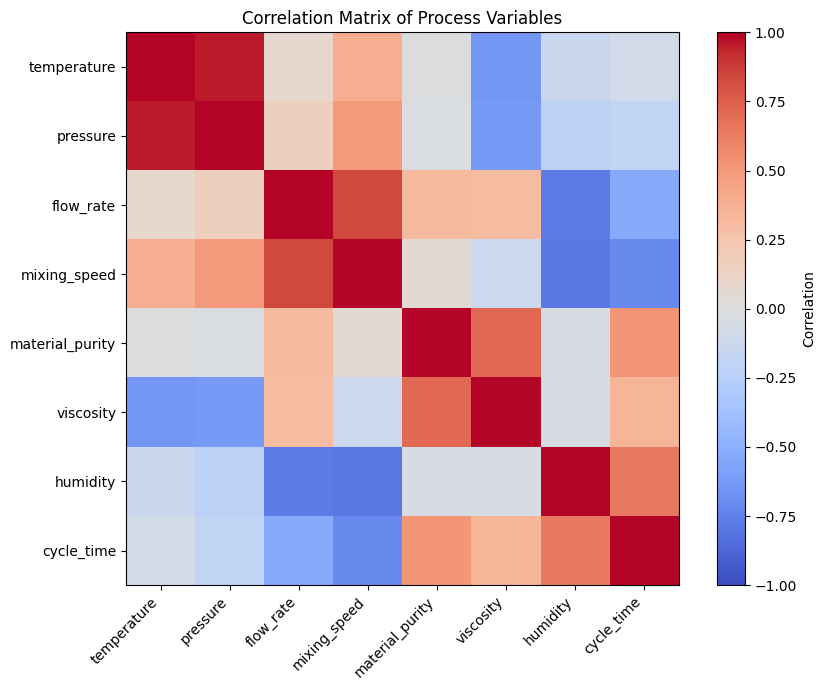

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    corr.values,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

ax.set_xticks(
    range(len(features)),
    labels=features,
    rotation=45,
    ha="right",
)
ax.set_yticks(
    range(len(features)),
    labels=features,
)

fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix of Process Variables")
plt.tight_layout()
plt.show()

## 10. Why Multicollinearity Matters / 多重共線性が問題になる理由

When predictors are strongly correlated:

- regression coefficients can become unstable
- coefficient signs may change unexpectedly
- interpretation becomes difficult
- small data changes can cause large coefficient changes

Prediction may still work, but individual coefficient interpretation becomes unreliable.

説明変数同士が強く相関すると、通常の回帰分析では係数が不安定になりやすくなります。

PLSは、相関した変数を少数の潜在成分へ圧縮して扱います。

## 11. Train-Test Split / 学習データとテストデータに分割

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (165, 8)
Test: (55, 8)


## 12. Baseline: Ordinary Linear Regression / ベースライン：通常の線形回帰

Before PLS, build a standard linear regression model as a baseline.

PLS should not automatically be assumed to be better.

まず通常の線形回帰をベースラインとして確認します。

In [10]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

linear_rmse = mean_squared_error(
    y_test,
    linear_pred,
) ** 0.5

linear_r2 = r2_score(
    y_test,
    linear_pred,
)

print(f"Linear Regression RMSE: {linear_rmse:.3f}")
print(f"Linear Regression R²:   {linear_r2:.3f}")

Linear Regression RMSE: 1.621
Linear Regression R²:   0.869


## 13. Choosing the Number of PLS Components / PLS成分数を選ぶ

PLS requires choosing the number of latent components.

Too few components may underfit.

Too many components may overfit.

We use 5-fold cross-validation and choose the number of components with the lowest validation RMSE.

PLSでは潜在成分数を決める必要があります。

ここでは5-fold cross-validationでRMSEを比較し、最も良い成分数を選びます。

In [11]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

component_results = []

max_components = min(
    len(features),
    8,
)

for n_components in range(1, max_components + 1):
    model = PLSRegression(
        n_components=n_components,
        scale=True,
    )

    neg_mse_scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_mean_squared_error",
        cv=cv,
    )

    rmse = np.sqrt(
        -neg_mse_scores.mean()
    )

    component_results.append({
        "n_components": n_components,
        "cv_rmse": rmse,
    })

cv_df = pd.DataFrame(component_results)
cv_df.round(4)

,n_components,cv_rmse
0,1,2.0421
1,2,1.7607
2,3,1.7455
3,4,1.7372
4,5,1.7362
5,6,1.7443
6,7,1.7445
7,8,1.7440


In [12]:
best_n = int(
    cv_df.loc[
        cv_df["cv_rmse"].idxmin(),
        "n_components",
    ]
)

print("Best number of components:", best_n)

Best number of components: 5


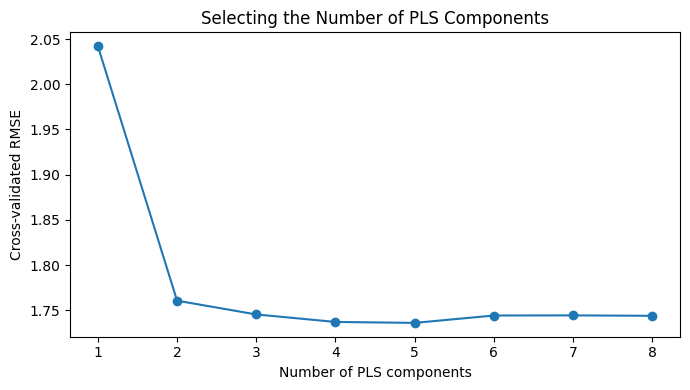

In [13]:
plt.figure(figsize=(7, 4))

plt.plot(
    cv_df["n_components"],
    cv_df["cv_rmse"],
    marker="o",
)

plt.xlabel("Number of PLS components")
plt.ylabel("Cross-validated RMSE")
plt.title("Selecting the Number of PLS Components")
plt.xticks(cv_df["n_components"])
plt.tight_layout()
plt.show()

## 14. Fit the Final PLS Model / 最終PLSモデルを学習する

Use the component count selected by cross-validation.

クロスバリデーションで選んだ成分数を使って最終モデルを学習します。

In [14]:
pls = PLSRegression(
    n_components=best_n,
    scale=True,
)

pls.fit(
    X_train,
    y_train,
)

pls_pred = pls.predict(X_test).ravel()

pls_rmse = mean_squared_error(
    y_test,
    pls_pred,
) ** 0.5

pls_r2 = r2_score(
    y_test,
    pls_pred,
)

print(f"PLS RMSE: {pls_rmse:.3f}")
print(f"PLS R²:   {pls_r2:.3f}")

PLS RMSE: 1.611
PLS R²:   0.870


## 15. Compare Linear Regression and PLS / 線形回帰とPLSを比較する

In [15]:
comparison = pd.DataFrame({
    "model": [
        "Linear Regression",
        "PLS Regression",
    ],
    "RMSE": [
        linear_rmse,
        pls_rmse,
    ],
    "R2": [
        linear_r2,
        pls_r2,
    ],
})

comparison.round(3)

,model,RMSE,R2
0,Linear Regression,1.621,0.869
1,PLS Regression,1.611,0.870


## 16. Actual vs Predicted / 実測値と予測値

If predictions are accurate, points should lie close to the diagonal line.

予測性能が良ければ、実測値と予測値は45度線の近くに分布します。

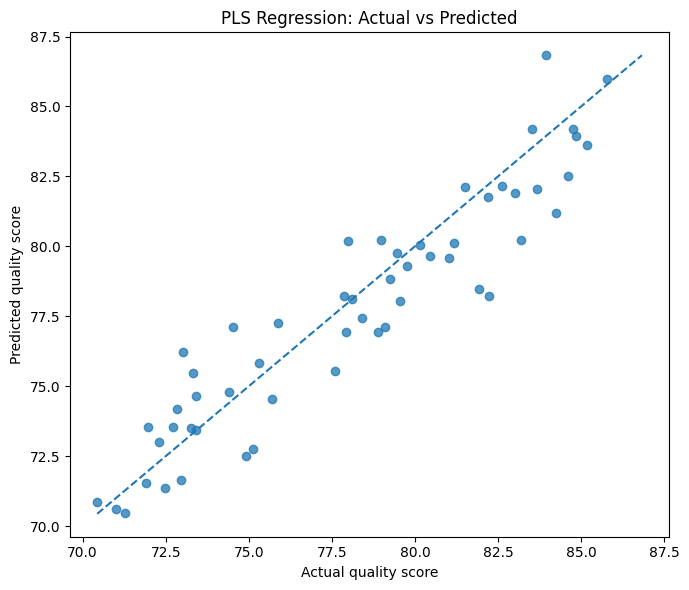

In [16]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    pls_pred,
    alpha=0.75,
)

minimum = min(
    y_test.min(),
    pls_pred.min(),
)

maximum = max(
    y_test.max(),
    pls_pred.max(),
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
)

plt.xlabel("Actual quality score")
plt.ylabel("Predicted quality score")
plt.title("PLS Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

## 17. Residuals / 残差を確認する

Residuals are:

`Actual - Predicted`

Large systematic patterns may suggest model misspecification.

残差に明確なパターンがないか確認します。

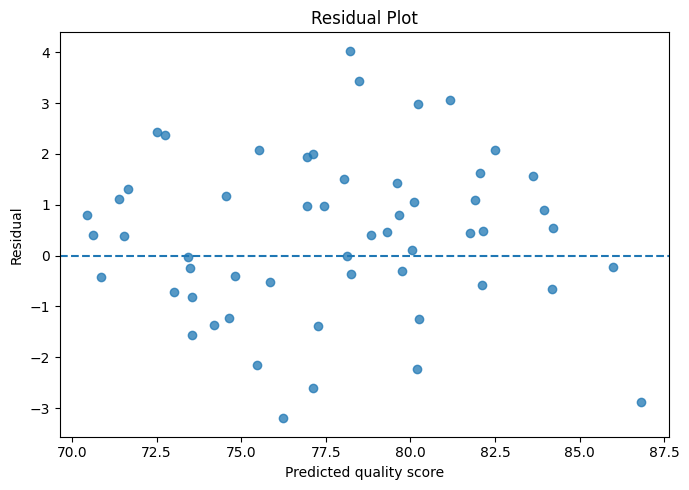

In [17]:
residuals = y_test.to_numpy() - pls_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    pls_pred,
    residuals,
    alpha=0.75,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Predicted quality score")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

## 18. PLS Regression Coefficients / PLS回帰係数

PLS ultimately produces regression coefficients for the original variables.

Because scaling is used, coefficient magnitudes can help indicate which variables are more influential in the model.

However, strongly correlated predictors should still be interpreted cautiously.

PLSでも最終的には元の説明変数に対する回帰係数を得られます。

ただし、説明変数間に強い相関があるため、係数を因果的に解釈しないことが重要です。

In [18]:
coef_values = np.asarray(pls.coef_).reshape(-1)

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": coef_values,
})

coef_df["abs_coefficient"] = (
    coef_df["coefficient"].abs()
)

coef_df.sort_values(
    "abs_coefficient",
    ascending=False,
).round(4)

,feature,coefficient,abs_coefficient
4,material_purity,0.4642,0.4642
5,viscosity,0.2199,0.2199
1,pressure,0.1446,0.1446
6,humidity,-0.1202,0.1202
2,flow_rate,0.0738,0.0738
7,cycle_time,-0.0597,0.0597
3,mixing_speed,0.0177,0.0177
0,temperature,0.0004,0.0004


## 19. Visualize PLS Coefficients / PLS係数の可視化

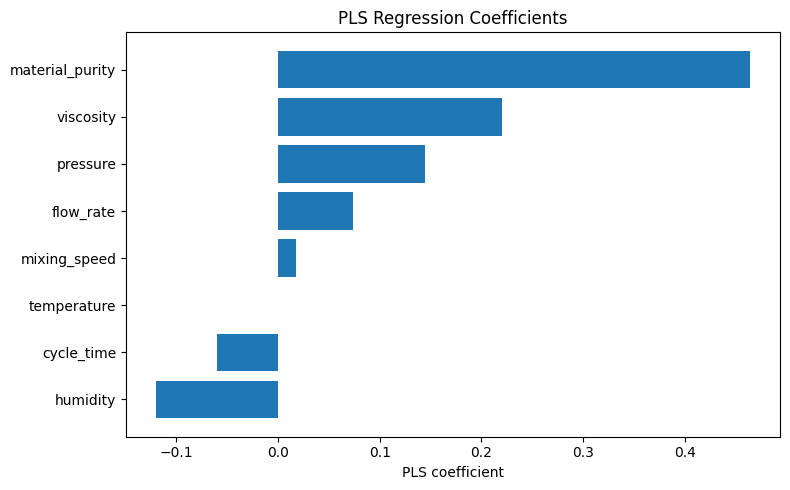

In [19]:
plot_df = (
    coef_df.sort_values("coefficient")
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"],
)

plt.xlabel("PLS coefficient")
plt.title("PLS Regression Coefficients")
plt.tight_layout()
plt.show()

## 20. Latent Scores / 潜在成分スコア

PLS transforms each observation into a lower-dimensional latent space.

`x_scores_` contains the coordinates of training observations on the PLS components.

PLSでは、元の説明変数を少数の潜在成分へ変換します。

`x_scores_`は、各学習データがPLS成分上でどこに位置するかを表します。

In [20]:
scores = pls.x_scores_

score_columns = [
    f"Component_{i+1}"
    for i in range(scores.shape[1])
]

score_df = pd.DataFrame(
    scores,
    columns=score_columns,
)

score_df.head()

,Component_1,Component_2,Component_3,Component_4,Component_5
0,-0.788879,-0.836914,-1.753837,-0.471527,-0.435360
1,-0.640386,0.717241,-0.197103,-1.244021,0.012957
2,0.168131,0.791313,-0.858754,0.582336,0.102875
3,-0.377944,-0.163931,-0.384337,-0.555761,-0.738981
4,-1.660164,2.717967,1.931961,-0.679966,-0.207839


## 21. Visualize the First Two PLS Components / 最初の2成分を可視化する

When at least two components are selected, we can visualize the latent space.

2成分以上ある場合、潜在空間を散布図で確認できます。

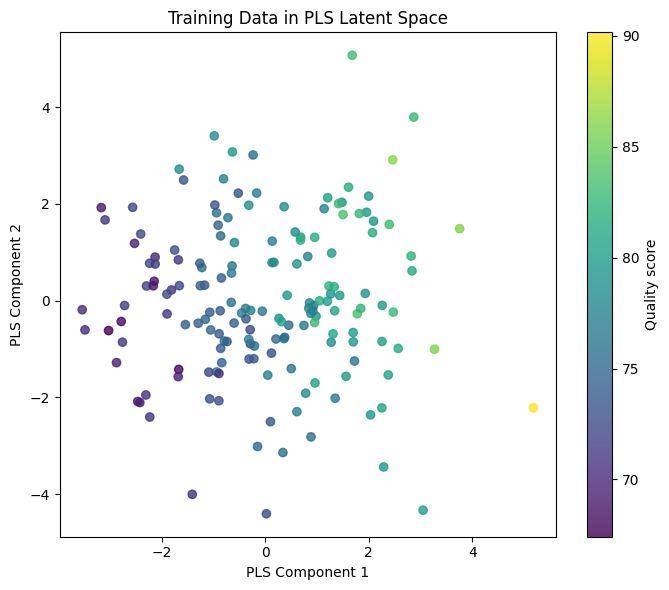

In [21]:
if scores.shape[1] >= 2:
    plt.figure(figsize=(7, 6))

    scatter = plt.scatter(
        scores[:, 0],
        scores[:, 1],
        c=y_train.to_numpy(),
        alpha=0.8,
    )

    plt.xlabel("PLS Component 1")
    plt.ylabel("PLS Component 2")
    plt.title("Training Data in PLS Latent Space")
    plt.colorbar(
        scatter,
        label="Quality score",
    )
    plt.tight_layout()
    plt.show()
else:
    print("Only one PLS component was selected.")

## 22. X Loadings / Xローディング

`x_loadings_` describes how the original variables relate to the latent components.

Large absolute loading values indicate variables that contribute strongly to a component.

`x_loadings_`を見ることで、各PLS成分がどの説明変数の影響を強く受けているか確認できます。

In [22]:
loading_columns = [
    f"Component_{i+1}"
    for i in range(pls.x_loadings_.shape[1])
]

loading_df = pd.DataFrame(
    pls.x_loadings_,
    index=features,
    columns=loading_columns,
)

loading_df.round(3)

,Component_1,Component_2,Component_3,Component_4,Component_5
temperature,0.180,-0.256,0.656,0.302,0.058
pressure,0.222,-0.287,0.618,0.176,-0.192
flow_rate,0.556,-0.094,-0.172,-0.184,0.816
mixing_speed,0.505,-0.312,0.039,-0.319,-0.089
material_purity,0.347,0.475,0.209,-0.003,-0.120
viscosity,0.203,0.503,-0.351,-0.273,-0.204
humidity,-0.472,0.226,0.266,-0.715,0.596
cycle_time,-0.182,0.508,0.302,0.613,0.066


## 23. How to Interpret PLS / PLSの解釈ポイント

PLS can be understood as a compromise between:

- dimensionality reduction
- regression

The model creates latent components that compress correlated predictors while retaining information useful for predicting the target.

PLSは、

- 次元削減
- 回帰

を同時に行うイメージです。

多数の相関した説明変数を少数の成分へ圧縮し、その中でも目的変数の予測に役立つ方向を優先します。

## 24. When Is PLS Useful? / PLSが向いている場面

PLS is often useful when:

- there are many predictors
- predictors are strongly correlated
- sample size is not extremely large relative to the number of predictors
- prediction is an important objective
- latent factors are plausible

Common examples include:

- spectroscopy
- chemical process analysis
- manufacturing quality prediction
- biological measurements
- marketing data with many correlated indicators

PLSは、製造・化学・バイオ・マーケティングなど、「説明変数が多く、しかも互いに相関している」場面でよく使われます。

## 25. Assumptions and Limitations / 前提条件と限界

Important considerations include:

- relationships are modeled approximately linearly
- the number of components should be selected using validation
- coefficients can still be difficult to interpret when predictors are correlated
- PLS is not automatically better than ordinary regression
- scaling choices affect the model
- outliers can influence latent components
- good prediction does not establish causation
- simulated data may be cleaner than real manufacturing data

主な注意点は次のとおりです。

- 基本的には線形関係をモデル化する
- 成分数はクロスバリデーションなどで決める
- 相関の強い変数では係数解釈に注意する
- PLSが常に通常回帰より優れているわけではない
- 標準化の方法が結果に影響する
- 外れ値が潜在成分へ影響する
- 予測精度が高くても因果関係を意味しない
- 今回は学習用シミュレーションデータである

## 26. Conclusion / まとめ

This Notebook applied PLS Regression to product-quality prediction with correlated process variables.

Workflow:

1. Load manufacturing process data
2. Examine correlations among predictors
3. Understand multicollinearity
4. Build a linear-regression baseline
5. Select the number of PLS components by cross-validation
6. Train the final PLS model
7. Evaluate RMSE and R²
8. Inspect actual vs predicted values and residuals
9. Interpret coefficients, scores, and loadings
10. Compare the role of PLS with PCA

The key idea is:

> PLS creates latent components that are useful both for summarizing X and predicting Y.

このNotebookでは、相関の強い工程変数から製品品質を予測するPLS回帰を扱いました。

重要なのは、

> PLSは、説明変数を圧縮しながら、目的変数の予測にも役立つ潜在成分を作る

という点です。